In [1]:
import pandas as pd

aviation = pd.read_csv(
    "../data/processed/aviation_clean.csv",
    parse_dates=["date"]
)

aviation.shape

(6758, 7)

In [2]:
monthly_traffic = (
    aviation.groupby("date")["total_passengers"]
    .sum()
    .reset_index()
)

monthly_traffic.head()

,date,total_passengers
0,2015-01-01,15849653
1,2015-02-01,15822571
2,2015-03-01,18788330
3,2015-04-01,20410151
4,2015-05-01,22761893


In [3]:
aviation.loc[
    aviation["airport_group"] == "Non UK Reporting Airports",
    "airport"
].unique()

<ArrowStringArray>
['ALDERNEY', 'GUERNSEY', 'ISLE OF MAN', 'JERSEY']
Length: 4, dtype: str

In [4]:
uk_aviation = aviation[
    aviation["airport_group"] != "Non UK Reporting Airports"
].copy()

uk_aviation["airport"].nunique()

55

In [5]:
monthly_traffic = (
    uk_aviation.groupby("date")["total_passengers"]
    .sum()
    .reset_index()
)

monthly_traffic.head()

,date,total_passengers
0,2015-01-01,15664021
1,2015-02-01,15617632
2,2015-03-01,18539452
3,2015-04-01,20148926
4,2015-05-01,22462867


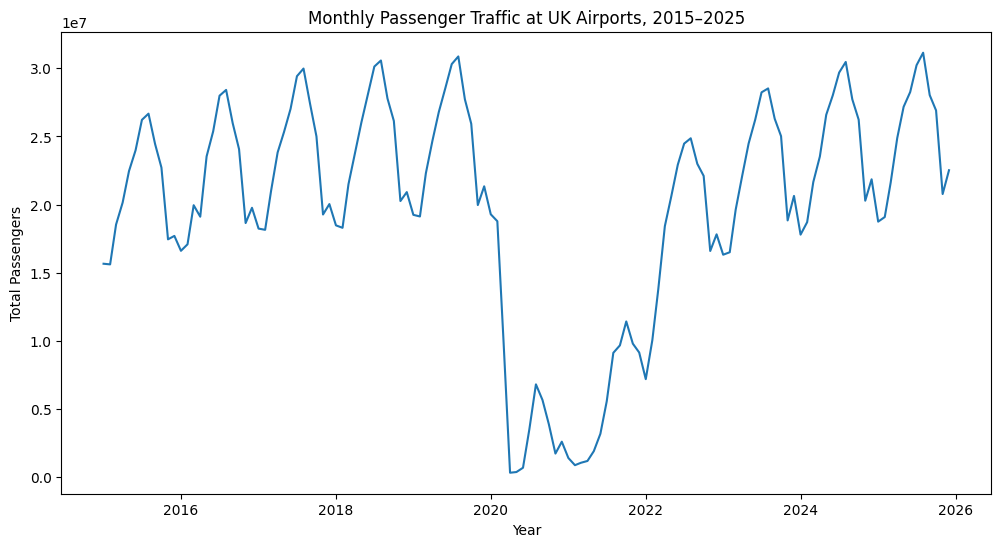

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(
    monthly_traffic["date"],
    monthly_traffic["total_passengers"]
)

plt.title("Monthly Passenger Traffic at UK Airports, 2015–2025")
plt.xlabel("Year")
plt.ylabel("Total Passengers")
plt.show()

In [7]:
monthly_traffic.loc[
    monthly_traffic["total_passengers"].idxmax()
]

date                2025-08-01 00:00:00
total_passengers               31143773
Name: 127, dtype: object

In [8]:
pre_covid = monthly_traffic[
    monthly_traffic["date"] < "2020-01-01"
]

pre_covid.loc[
    pre_covid["total_passengers"].idxmax()
]

date                2019-08-01 00:00:00
total_passengers               30870746
Name: 55, dtype: object

In [9]:
pre_covid_peak = 30870746
peak_2025 = 31143773

percentage_change = (
    (peak_2025 - pre_covid_peak) / pre_covid_peak
) * 100

round(percentage_change, 2)

0.88

In [10]:
monthly_traffic.loc[
    monthly_traffic["total_passengers"].idxmin()
]

date                2020-04-01 00:00:00
total_passengers                 334635
Name: 63, dtype: object

In [11]:
pre_covid_peak = 30870746
covid_low = 334635

covid_decline = (
    (covid_low - pre_covid_peak) / pre_covid_peak
) * 100

round(covid_decline, 2)

-98.92

In [12]:
monthly_traffic[
    monthly_traffic["date"].isin(["2019-04-01", "2020-04-01"])
]

,date,total_passengers


In [13]:
monthly_traffic[
    monthly_traffic["date"].dt.month == 4
]

,date,total_passengers
3,2015-04-01,20148926
15,2016-04-01,19115854
27,2017-04-01,23832495
39,2018-04-01,23789224
51,2019-04-01,24690108
63,2020-04-01,334635
75,2021-04-01,1197039
87,2022-04-01,18422215
99,2023-04-01,22136140
111,2024-04-01,23531787


In [14]:
monthly_traffic[
    (monthly_traffic["date"].dt.year == 2019) &
    (monthly_traffic["date"].dt.month == 4)
]

,date,total_passengers
51,2019-04-01,24690108


In [15]:
monthly_traffic[
    (monthly_traffic["date"].dt.year == 2020) &
    (monthly_traffic["date"].dt.month == 4)
]

,date,total_passengers
63,2020-04-01,334635


In [16]:
april_2019 = 24690108
april_2020 = 334635

april_change = (
    (april_2020 - april_2019) / april_2019
) * 100

round(april_change, 2)

-98.64

In [18]:
uk_aviation["year"] = uk_aviation["date"].dt.year
uk_aviation[["date", "year"]].head()

,date,year
0,2015-01-01,2015
2,2015-01-01,2015
3,2015-01-01,2015
4,2015-01-01,2015
5,2015-01-01,2015


In [19]:
annual_traffic = (
    uk_aviation.groupby("year")["total_passengers"]
    .sum()
    .reset_index()
)

annual_traffic

,year,total_passengers
0,2015,251640681
1,2016,266565594
2,2017,284708287
3,2018,292014055
4,2019,296880158
5,2020,73794074
6,2021,64442194
7,2022,221856952
8,2023,272879792
9,2024,292569830


In [20]:
passengers_2019 = 296880158
passengers_2025 = 299416087

recovery_change = (
    (passengers_2025 - passengers_2019) / passengers_2019
) * 100

round(recovery_change, 2)

0.85

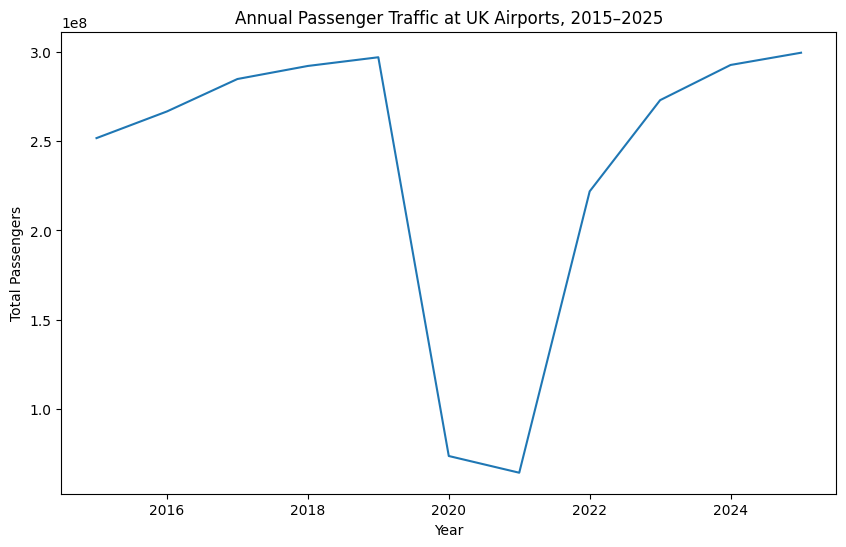

In [21]:
plt.figure(figsize=(10, 6))

plt.plot(
    annual_traffic["year"],
    annual_traffic["total_passengers"]
)

plt.title("Annual Passenger Traffic at UK Airports, 2015–2025")
plt.xlabel("Year")
plt.ylabel("Total Passengers")

plt.show()

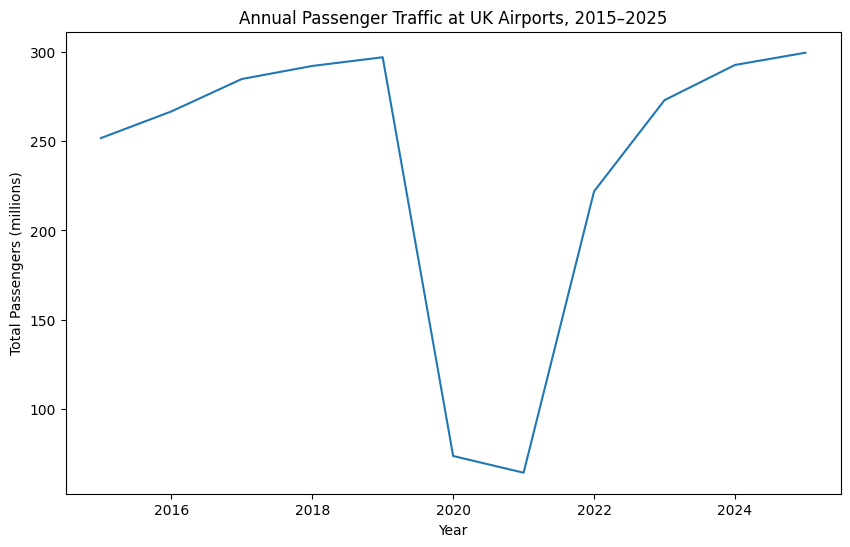

In [22]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(10, 6))

plt.plot(
    annual_traffic["year"],
    annual_traffic["total_passengers"]
)

plt.title("Annual Passenger Traffic at UK Airports, 2015–2025")
plt.xlabel("Year")
plt.ylabel("Total Passengers (millions)")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x / 1_000_000:.0f}")
)

plt.show()

In [23]:
passengers_2015 = 251640681
passengers_2019 = 296880158

pre_covid_growth = (
    (passengers_2019 - passengers_2015) / passengers_2015
) * 100

round(pre_covid_growth, 2)

17.98

In [24]:
aviation_2025 = uk_aviation[
    uk_aviation["year"] == 2025
].copy()

aviation_2025.shape

(545, 8)

In [25]:
airport_2025 = (
    aviation_2025.groupby("airport")["total_passengers"]
    .sum()
    .reset_index()
)

airport_2025.head()

,airport,total_passengers
0,ABERDEEN,2301978
1,BARRA,11822
2,BELFAST CITY (GEORGE BEST),2363781
3,BELFAST INTERNATIONAL,6677021
4,BENBECULA,26251


In [29]:
top_10_airports_2025 = (
    airport_2025
    .sort_values("total_passengers", ascending=False)
    .head(10)
     .reset_index(drop=True)
)

top_10_airports_2025

,airport,total_passengers
0,HEATHROW,84481178
1,GATWICK,42775241
2,MANCHESTER,32072136
3,STANSTED,29758490
4,LUTON,17770247
5,EDINBURGH,16970143
6,BIRMINGHAM,13663877
7,BRISTOL,10833730
8,GLASGOW,8207395
9,BELFAST INTERNATIONAL,6677021


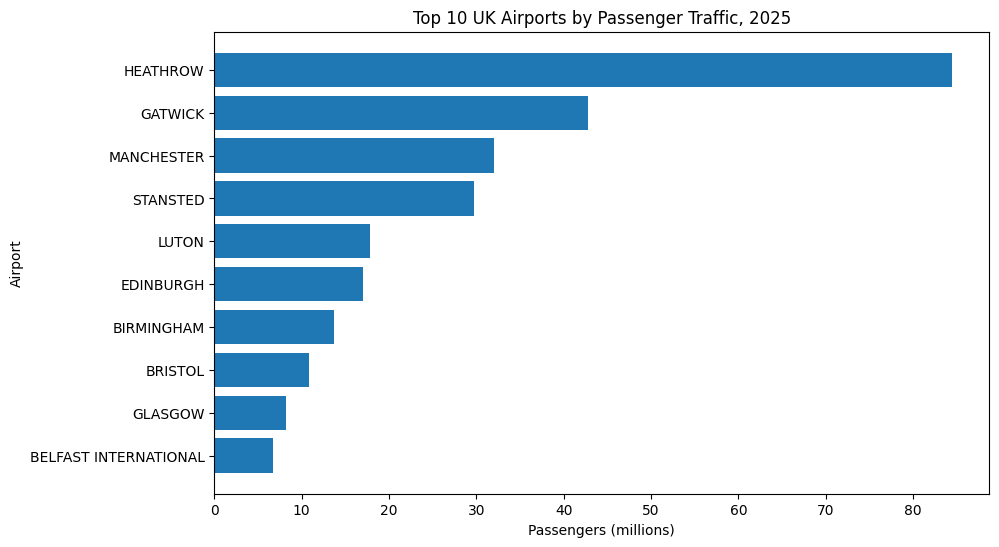

In [30]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_10_airports_2025["airport"],
    top_10_airports_2025["total_passengers"] / 1_000_000
)

plt.title("Top 10 UK Airports by Passenger Traffic, 2025")
plt.xlabel("Passengers (millions)")
plt.ylabel("Airport")

plt.gca().invert_yaxis()

plt.show()

In [33]:
airport_2019 = (
    uk_aviation[uk_aviation["year"] == 2019]
    .groupby("airport")["total_passengers"]
    .sum()
    .reset_index()
)

airport_2019.head()

,airport,total_passengers
0,ABERDEEN,2912883
1,BARRA,14599
2,BELFAST CITY (GEORGE BEST),2455259
3,BELFAST INTERNATIONAL,6278563
4,BENBECULA,34691


In [34]:
airport_comparison = airport_2019.merge(
    airport_2025,
    on="airport",
    suffixes=("_2019", "_2025")
)

airport_comparison.head()

,airport,total_passengers_2019,total_passengers_2025
0,ABERDEEN,2912883,2301978
1,BARRA,14599,11822
2,BELFAST CITY (GEORGE BEST),2455259,2363781
3,BELFAST INTERNATIONAL,6278563,6677021
4,BENBECULA,34691,26251


In [35]:
airport_comparison["percentage_change"] = (
    (
        airport_comparison["total_passengers_2025"]
        - airport_comparison["total_passengers_2019"]
    )
    / airport_comparison["total_passengers_2019"]
) * 100

airport_comparison.head()

,airport,total_passengers_2019,total_passengers_2025,percentage_change
0,ABERDEEN,2912883,2301978,-20.972521
1,BARRA,14599,11822,-19.021851
2,BELFAST CITY (GEORGE BEST),2455259,2363781,-3.725798
3,BELFAST INTERNATIONAL,6278563,6677021,6.346325
4,BENBECULA,34691,26251,-24.329077


In [36]:
airport_comparison["percentage_change"] = (
    airport_comparison["percentage_change"].round(2)
)

airport_comparison.head()

,airport,total_passengers_2019,total_passengers_2025,percentage_change
0,ABERDEEN,2912883,2301978,-20.97
1,BARRA,14599,11822,-19.02
2,BELFAST CITY (GEORGE BEST),2455259,2363781,-3.73
3,BELFAST INTERNATIONAL,6278563,6677021,6.35
4,BENBECULA,34691,26251,-24.33


In [37]:
major_airports = airport_comparison[
    airport_comparison["total_passengers_2019"] >= 5_000_000
].copy()

major_airports.shape

(13, 4)

In [38]:
major_airports = major_airports.sort_values(
    "percentage_change",
    ascending=False
).reset_index(drop=True)

major_airports

,airport,total_passengers_2019,total_passengers_2025,percentage_change
0,BRISTOL,8964242,10833730,20.85
1,EDINBURGH,14737497,16970143,15.15
2,LIVERPOOL (JOHN LENNON),5002192,5611423,12.18
3,MANCHESTER,29397358,32072136,9.10
4,BIRMINGHAM,12650607,13663877,8.01
5,BELFAST INTERNATIONAL,6278563,6677021,6.35
6,STANSTED,28124292,29758490,5.81
7,NEWCASTLE,5203624,5480401,5.32
8,HEATHROW,80890031,84481178,4.44
9,LUTON,18216207,17770247,-2.45


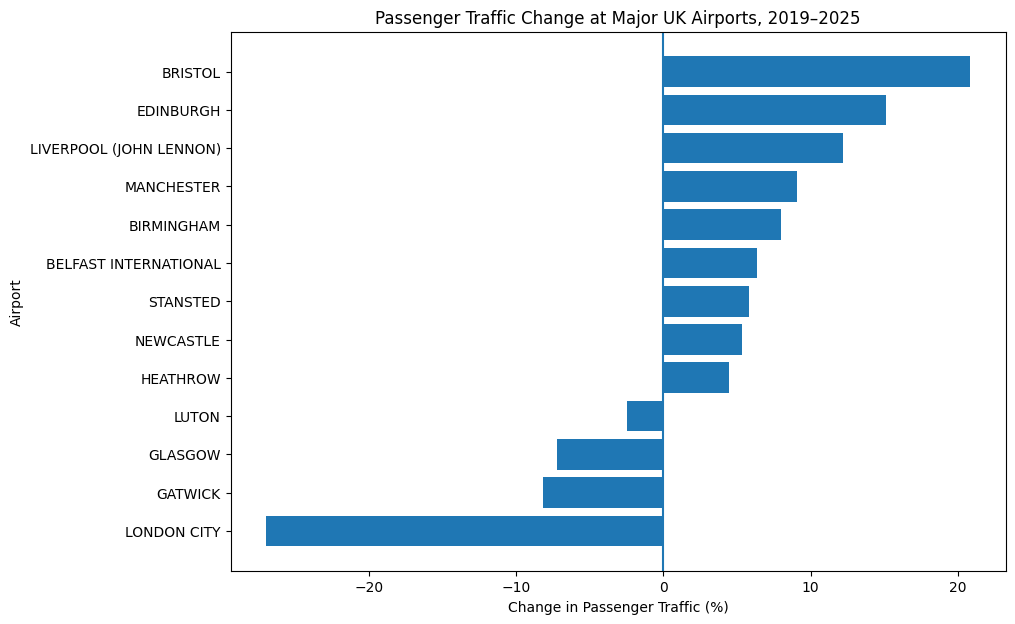

In [39]:
plt.figure(figsize=(10, 7))

plt.barh(
    major_airports["airport"],
    major_airports["percentage_change"]
)

plt.axvline(0)

plt.title("Passenger Traffic Change at Major UK Airports, 2019–2025")
plt.xlabel("Change in Passenger Traffic (%)")
plt.ylabel("Airport")

plt.gca().invert_yaxis()

plt.show()

In [40]:
monthly_traffic["month"] = monthly_traffic["date"].dt.month

seasonality = (
    monthly_traffic.groupby("month")["total_passengers"]
    .mean()
    .reset_index()
)

seasonality

,month,total_passengers
0,1,1.536701e+07
1,2,1.566700e+07
2,3,1.737553e+07
3,4,1.837226e+07
4,5,2.048129e+07
5,6,2.203455e+07
6,7,2.416394e+07
7,8,2.522410e+07
8,9,2.306565e+07
9,10,2.176818e+07


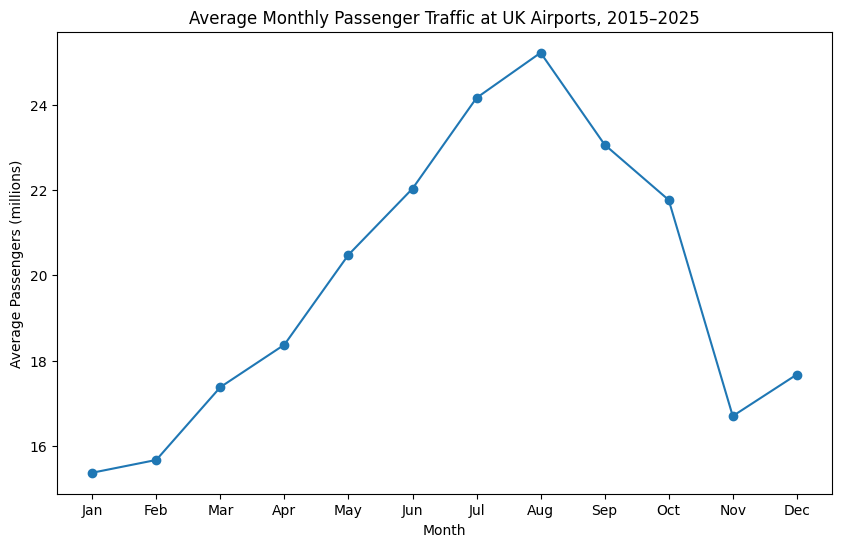

In [42]:
plt.figure(figsize=(10, 6))

plt.plot(
    seasonality["month"],
    seasonality["total_passengers"] / 1_000_000,
    marker="o"
)

plt.title("Average Monthly Passenger Traffic at UK Airports, 2015–2025")
plt.xlabel("Month")
plt.ylabel("Average Passengers (millions)")

plt.xticks(
    range(1, 13),
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)

plt.show()

In [43]:
pre_covid_monthly = monthly_traffic[
    monthly_traffic["date"].dt.year <= 2019
]

recent_monthly = monthly_traffic[
    monthly_traffic["date"].dt.year >= 2022
]

pre_covid_monthly.shape, recent_monthly.shape

((60, 3), (48, 3))

In [44]:
pre_covid_seasonality = (
    pre_covid_monthly.groupby("month")["total_passengers"]
    .mean()
    .reset_index()
)

recent_seasonality = (
    recent_monthly.groupby("month")["total_passengers"]
    .mean()
    .reset_index()
)

pre_covid_seasonality

,month,total_passengers
0,1,17650151.2
1,2,17658664.0
2,3,20661565.0
3,4,22315321.4
4,5,24832043.4
5,6,26610920.0
6,7,28814299.0
7,8,29303178.8
8,9,26664759.2
9,10,24772172.2


In [45]:
recent_seasonality

,month,total_passengers
0,1,15019762.25
1,2,16093154.50
2,3,19175904.75
3,4,22246640.25
4,5,24707957.00
5,6,26358949.25
6,7,28157491.25
7,8,28750704.50
8,9,26263881.25
9,10,25067603.25


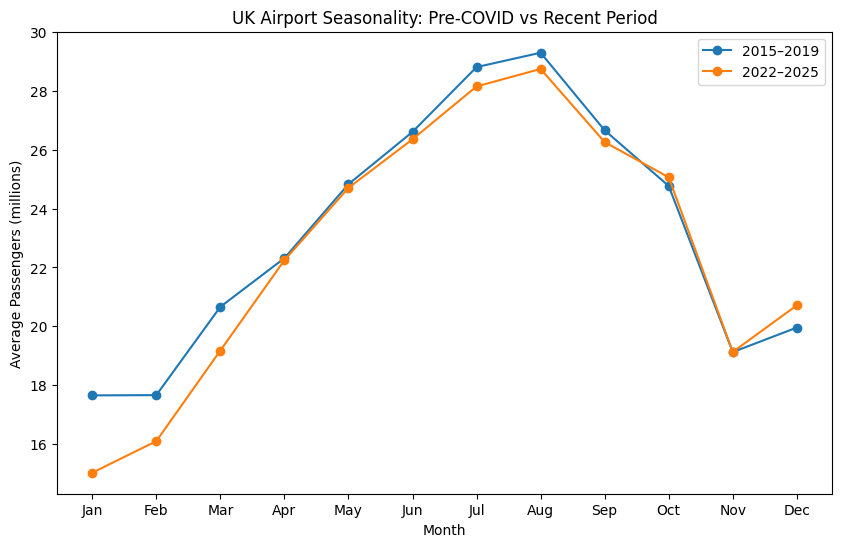

In [46]:
plt.figure(figsize=(10, 6))

plt.plot(
    pre_covid_seasonality["month"],
    pre_covid_seasonality["total_passengers"] / 1_000_000,
    marker="o",
    label="2015–2019"
)

plt.plot(
    recent_seasonality["month"],
    recent_seasonality["total_passengers"] / 1_000_000,
    marker="o",
    label="2022–2025"
)

plt.title("UK Airport Seasonality: Pre-COVID vs Recent Period")
plt.xlabel("Month")
plt.ylabel("Average Passengers (millions)")

plt.xticks(
    range(1, 13),
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)

plt.legend()

plt.show()

## Key Findings

- UK airport passenger traffic grew by **18.0% between 2015 and 2019**, rising from 251.6 million to 296.9 million passengers.
- The COVID-19 pandemic caused an unprecedented collapse in aviation activity. Passenger traffic in **April 2020 was 98.6% lower than April 2019**.
- By **2025**, annual passenger traffic had reached 299.4 million, **0.85% above the 2019 pre-COVID level**.
- Recovery varied substantially between major airports. **Bristol (+20.85%)**, **Edinburgh (+15.15%)**, and **Liverpool (+12.18%)** recorded strong growth between 2019 and 2025, while **Gatwick (-8.16%)** and **London City (-27.02%)** remained below their 2019 levels.
- Heathrow remained the UK's busiest airport in 2025, handling approximately **84.5 million passengers**.
- UK airport traffic displays strong seasonality, generally rising through spring and summer and **peaking in August**.
- The seasonal pattern in 2022–2025 broadly resembles the pre-COVID pattern, suggesting that the underlying seasonal structure of UK passenger traffic has largely re-established itself.